In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from collections import Counter

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...


[nltk_data]   Unzipping tokenizers/punkt.zip.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
data = {
    "complaint": [
        "My debit card transaction was declined even though I had sufficient balance",
        "Money was deducted twice for a single transaction at the ATM",
        "I did not receive a refund for a failed transaction",
        "Unauthorized transaction happened on my account without my knowledge",
        "The fund transfer to another account failed but amount was debited",
        "I was charged extra transaction fee which was not informed earlier",
        "My NEFT transaction is still pending since three days",
        "Wrong amount was debited from my account during online payment",
        "Transaction history is not matching with my passbook entries",
        "Credit card payment transaction shows failed but amount was deducted",

        "My loan application is pending approval for a very long time",
        "I am being charged high interest rate than what was promised",
        "Loan EMI was deducted twice in the same month",
        "I did not get proper information about loan foreclosure charges",
        "My home loan disbursement is delayed without any reason",
        "The loan officer is not responding to my calls regarding loan status",
        "I was denied a personal loan without proper explanation",
        "Loan prepayment penalty was charged which was not mentioned before",
        "My loan closure certificate has not been issued yet",
        "Interest calculation on my loan account seems incorrect",

        "I am unable to login to my net banking account",
        "The mobile banking app keeps crashing every time I open it",
        "OTP is not received while doing online banking transaction",
        "My net banking password reset is not working",
        "Online banking portal is showing error while checking balance",
        "I am facing issues while paying bills through the mobile app",
        "Unable to update my mobile number for online banking",
        "The app does not show my recent transactions properly",
        "Net banking session keeps expiring too quickly",
        "I could not add a new beneficiary in online banking",

        "My account was frozen without any prior notice",
        "I want to close my account but branch staff is not cooperating",
        "There is an error in my account statement details",
        "My KYC update request is still not processed",
        "Wrong personal details are shown in my account profile",
        "I did not receive my new chequebook after requesting it",
        "My account got debited with unknown charges every month",
        "Nominee details in my account were not updated as requested",
        "I am unable to link my Aadhar card with my bank account",
        "My account statement is not generated for the requested period",
    ],
    "category": [
        "Transactions","Transactions","Transactions","Transactions","Transactions",
        "Transactions","Transactions","Transactions","Transactions","Transactions",
        "Loans","Loans","Loans","Loans","Loans",
        "Loans","Loans","Loans","Loans","Loans",
        "Online Banking","Online Banking","Online Banking","Online Banking","Online Banking",
        "Online Banking","Online Banking","Online Banking","Online Banking","Online Banking",
        "Account Management","Account Management","Account Management","Account Management","Account Management",
        "Account Management","Account Management","Account Management","Account Management","Account Management",
    ]
}

df = pd.DataFrame(data)
df.head()

,complaint,category
0,My debit card transaction was declined even th...,Transactions
1,Money was deducted twice for a single transact...,Transactions
2,I did not receive a refund for a failed transa...,Transactions
3,Unauthorized transaction happened on my accoun...,Transactions
4,The fund transfer to another account failed bu...,Transactions


In [3]:
print("Total complaints:", len(df))
df['category'].value_counts()

Total complaints: 40


category
Transactions          10
Loans                 10
Online Banking        10
Account Management    10
Name: count, dtype: int64

In [4]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_complaint'] = df['complaint'].apply(preprocess)
df[['complaint', 'clean_complaint']].head()

,complaint,clean_complaint
0,My debit card transaction was declined even th...,debit card transaction declined even though su...
1,Money was deducted twice for a single transact...,money deducted twice single transaction atm
2,I did not receive a refund for a failed transa...,receive refund failed transaction
3,Unauthorized transaction happened on my accoun...,unauthorized transaction happened account with...
4,The fund transfer to another account failed bu...,fund transfer another account failed amount de...


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_complaint'], df['category'], test_size=0.25, random_state=42
)

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9
                    precision    recall  f1-score   support

Account Management       1.00      1.00      1.00         2
             Loans       1.00      0.75      0.86         4
    Online Banking       1.00      1.00      1.00         2
      Transactions       0.67      1.00      0.80         2

          accuracy                           0.90        10
         macro avg       0.92      0.94      0.91        10
      weighted avg       0.93      0.90      0.90        10



In [6]:
def predict_category(complaint_text):
    cleaned = preprocess(complaint_text)
    vec = vectorizer.transform([cleaned])
    return model.predict(vec)[0]

sample_complaint = "The app is not letting me login and OTP is not coming"
print("Predicted Category:", predict_category(sample_complaint))

Predicted Category: Online Banking


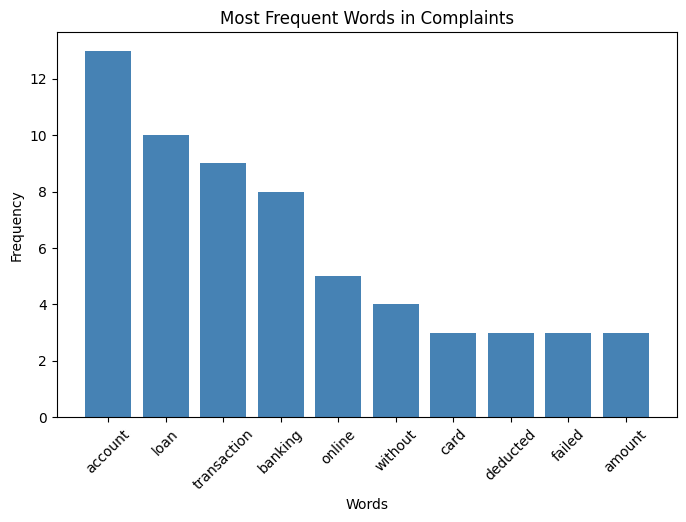

In [7]:
all_words = " ".join(df['clean_complaint']).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(10)

words, counts = zip(*common_words)
plt.figure(figsize=(8,5))
plt.bar(words, counts, color='steelblue')
plt.title("Most Frequent Words in Complaints")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

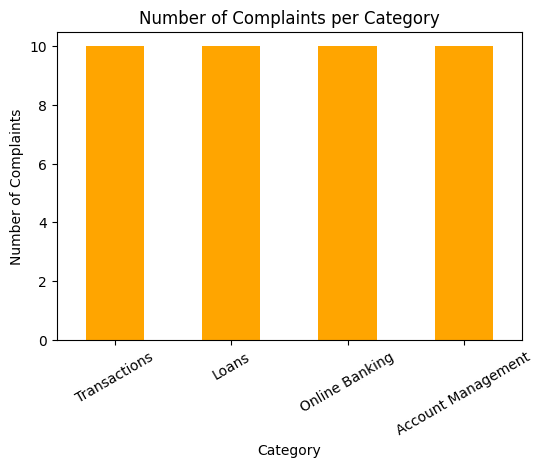

In [8]:
plt.figure(figsize=(6,4))
df['category'].value_counts().plot(kind='bar', color='orange')
plt.title("Number of Complaints per Category")
plt.xlabel("Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=30)
plt.show()

In [9]:
report = []
report.append("BANKING COMPLAINT ANALYSIS REPORT")
report.append("="*40)
report.append(f"Total Complaints Analyzed: {len(df)}")
report.append("")
report.append("Category wise Complaint Count:")
for cat, count in df['category'].value_counts().items():
    report.append(f" - {cat}: {count}")
report.append("")
report.append("Top 10 Frequent Words in Complaints:")
for word, freq in common_words:
    report.append(f" - {word}: {freq}")
report.append("")
report.append(f"Model Accuracy on Test Data: {round(accuracy_score(y_test, y_pred)*100, 2)}%")

final_report = "\n".join(report)
print(final_report)

with open("Banking_Complaint_Report.txt", "w") as f:
    f.write(final_report)

BANKING COMPLAINT ANALYSIS REPORT
Total Complaints Analyzed: 40

Category wise Complaint Count:
 - Transactions: 10
 - Loans: 10
 - Online Banking: 10
 - Account Management: 10

Top 10 Frequent Words in Complaints:
 - account: 13
 - loan: 10
 - transaction: 9
 - banking: 8
 - online: 5
 - without: 4
 - card: 3
 - deducted: 3
 - failed: 3
 - amount: 3

Model Accuracy on Test Data: 90.0%
